In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Given data
vector1 = np.array([2, 3, 4, 6, 8, 7, 6, 5, 4, 3, 2])
vector2 = np.array([2, 4, 6, 7, 7, 6, 5, 5, 4, 3, 2, 2, 1])

# Task 1: *Plot both vectors to visualize their patterns*

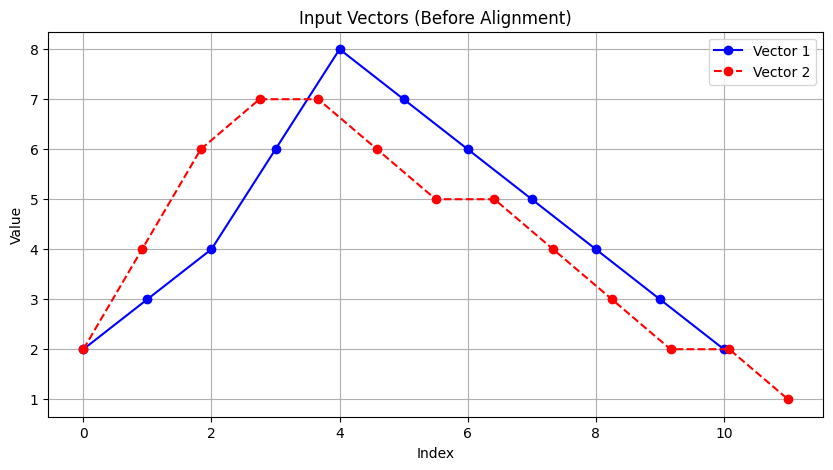

In [3]:
# --- Step 1: Plot both vectors ---
plt.figure(figsize=(10,5))
plt.plot(vector1, 'b-o', label='Vector 1')
plt.plot(np.linspace(0, len(vector1), len(vector2)), vector2, 'r--o', label='Vector 2')
plt.title("Input Vectors (Before Alignment)")
plt.xlabel("Index")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.show()

# Interpretation of the Plot – Input Vectors (Before Alignment)

This plot compares Vector 1 (blue) and Vector 2 (red) before applying any alignment method such as DTW. Both vectors represent similar overall patterns — a rise to a peak followed by a decline — but they differ in length and timing.

**1. Temporal Distortion:**

Vector 2 contains more samples and extends further along the x-axis, showing it is stretched in time relative to Vector 1.

This indicates that the same underlying pattern occurs at a slower pace or with local timing shifts.

**2. Shape Similarity:**

Both vectors have comparable amplitude trends — rising to a high point and then falling — meaning their structural shape is similar, though not synchronized.

**3. Misalignment of Peaks:**

The peak values occur at slightly different indices, showing that corresponding features (like local maxima or minima) are not temporally aligned.

This mismatch prevents direct comparison using simple distance measures like Euclidean distance.

**4. Inference:**

The figure illustrates the need for time-warping techniques such as Dynamic Time Warping (DTW) to handle such non-linear distortions.

DTW will later adjust the time axis of Vector 2 to align these patterns properly, minimizing temporal mismatch.

# Task 2: *Implement the Dynamic Time Warping (DTW) algorithm*

In [4]:
# --- Step 2: Implement DTW Algorithm ---
def dtw(v1, v2):
    n, m = len(v1), len(v2)
    dtw_matrix = np.full((n+1, m+1), np.inf)
    dtw_matrix[0,0] = 0

    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = abs(v1[i-1] - v2[j-1])
            dtw_matrix[i,j] = cost + min(dtw_matrix[i-1,j], dtw_matrix[i,j-1], dtw_matrix[i-1,j-1])
    return dtw_matrix

dtw_matrix = dtw(vector1, vector2)

In this step, the DTW algorithm builds a cost matrix that compares every point in Vector 1 with every point in Vector 2.
It then finds the lowest-cost path through this matrix by allowing diagonal, vertical, and horizontal moves—essentially stretching or compressing parts of one sequence so both patterns align in time as closely as possible.

# Task 3: *Compute the accumulated cost matrix*

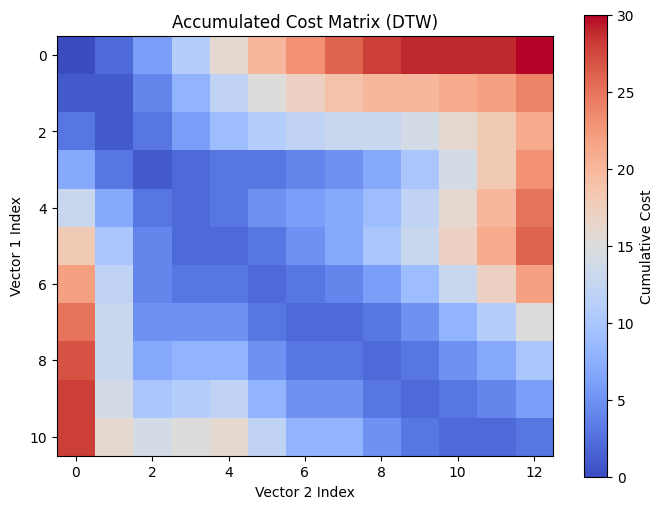

In [5]:
# --- Step 3: Visualize cost matrix ---
plt.figure(figsize=(8,6))
plt.imshow(dtw_matrix[1:,1:], interpolation='nearest', cmap='coolwarm')
plt.title("Accumulated Cost Matrix (DTW)")
plt.xlabel("Vector 2 Index")
plt.ylabel("Vector 1 Index")
plt.colorbar(label='Cumulative Cost')
plt.show()

# Interpretation of the Accumulated Cost Matrix (DTW)

This heatmap represents the accumulated cost matrix generated during Dynamic Time Warping. Each cell
(
𝑖
,
𝑗
)
(i,j) shows the total minimum cost of aligning the first i samples of Vector 1 with the first j samples of Vector 2.

The color scale (blue → red) indicates cumulative cost — blue regions represent areas of low alignment cost (good matches), while red regions show high cost (mismatched regions).

The smooth blue diagonal band running across the matrix suggests that the two sequences share similar overall trends but with local time distortions (slight stretching or shifting).

The edges turning red indicate points where the alignment required more “warping effort” to stay synchronized.

# Task 4: *Find and visualize the optimal warping path*

In [6]:
# --- Step 4: Find optimal path ---
def dtw_path(dtw_matrix):
    i, j = np.array(dtw_matrix.shape) - 1
    path = [(i-1, j-1)]
    while i>1 or j>1:
        options = [(i-1, j-1), (i-1, j), (i, j-1)]
        costs = [dtw_matrix[o] for o in options]
        min_idx = np.argmin(costs)
        i, j = options[min_idx]
        path.append((i-1, j-1))
    path.reverse()
    return path

path = dtw_path(dtw_matrix)
px, py = zip(*path)

This step retraces the optimal alignment path through the DTW cost matrix — the route that shows how the two sequences best match each other in time.

Starting from the bottom-right corner (where both sequences end), the algorithm moves backward through the matrix by always choosing the neighboring cell with the smallest accumulated cost.
This backtracking process continues until it reaches the top-left corner, effectively mapping the lowest-cost, non-linear alignment path between Vector 1 and Vector 2.

# Task 5: *Calculate the DTW distance*

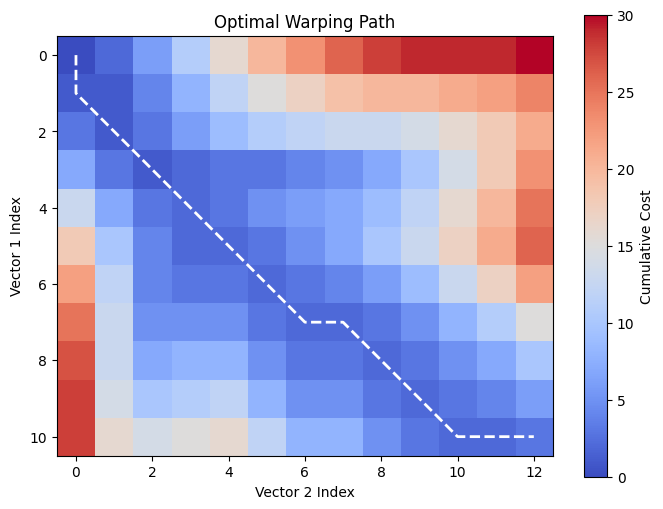

In [7]:
# --- Step 5: Visualize warping path ---
plt.figure(figsize=(8,6))
plt.imshow(dtw_matrix[1:,1:], cmap='coolwarm', interpolation='nearest')
plt.plot(py, px, 'w--', lw=2)
plt.title("Optimal Warping Path")
plt.xlabel("Vector 2 Index")
plt.ylabel("Vector 1 Index")
plt.colorbar(label='Cumulative Cost')
plt.show()

### **Interpretation of the Optimal Warping Path (DTW) Plot**

This plot shows the **optimal warping path** (white dashed line) superimposed on the **DTW accumulated cost matrix**.

* Each point along the white line represents a **pair of samples** — one from **Vector 1** and one from **Vector 2** — that DTW has aligned together to minimize the total cumulative cost.
* The **path bends and curves** away from the perfect diagonal, which means that DTW has performed **local stretching or compression** to synchronize regions where one vector lags or leads in time.
* Areas where the path moves **horizontally or vertically** indicate segments where one sequence is **temporarily stretched**, while diagonal portions show **direct one-to-one matching**.
* The path generally follows the **low-cost (blue) region**, confirming that DTW found the most efficient alignment between the two sequences despite their temporal distortions.



In [8]:
# --- Step 6: DTW Distance ---
dtw_distance = dtw_matrix[-1, -1]
print(f"DTW Distance between vectors: {dtw_distance:.2f}")

DTW Distance between vectors: 3.00


# **Meaning of the DTW Distance**
The DTW distance = 3.00 represents the total minimal cumulative cost required to optimally align Vector 1 and Vector 2(DTW distance ≈ “how much effort (cost)” the algorithm had to put in to make two sequences align)

In simple words, it tells us how similar the two sequences are after time-warping.


---


0 → Perfect match (identical sequences)

Small value (like 1–5) → Very similar (only small timing differences)

Moderate value (say 10–20) → Partially similar (needs moderate stretching/compression)

High value (above 20–30 in your scale) → Quite different sequences


---


A smaller DTW distance means the sequences are very similar — only a small amount of stretching or compressing was needed to match them.

A larger DTW distance would mean the sequences are quite different — the algorithm had to do a lot of “warping” to make them line up.



---
Since the DTW distance is 3.00, it indicates that the two vectors are highly similar in shape, and only minimal time distortion was required for alignment.
This confirms that both sequences follow nearly the same pattern but are slightly shifted or stretched in time.


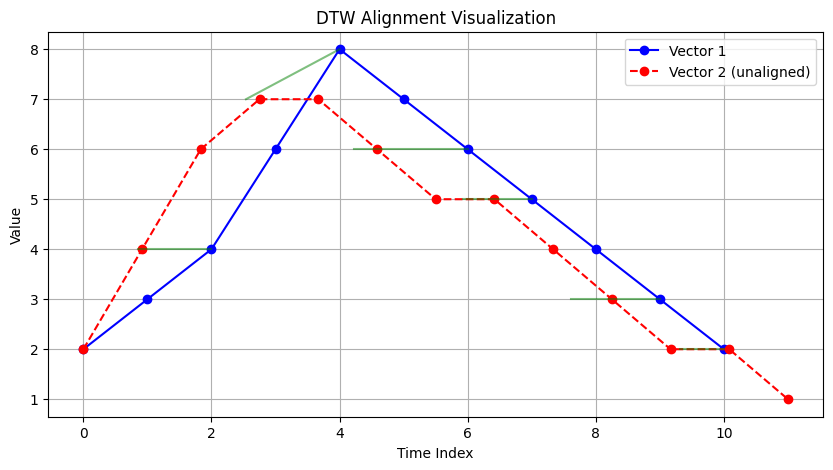

In [15]:
# --- Step 7: Overlay alignment visualization ---
plt.figure(figsize=(10,5))
plt.plot(vector1, 'b-o', label='Vector 1')
plt.plot(np.linspace(0, len(vector1), len(vector2)), vector2, 'r--o', label='Vector 2 (unaligned)')
for (i,j) in path[::2]:  # plot every other to declutter
    plt.plot([i, j*len(vector1)/len(vector2)], [vector1[i], vector2[j]], 'green', alpha=0.5)
plt.title("DTW Alignment Visualization")
plt.xlabel("Time Index")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.show()

# Interpretation of the DTW Alignment Visualization

This plot visually demonstrates how Dynamic Time Warping (DTW) aligns the two sequences — Vector 1 (blue) and Vector 2 (red) — even though they are not perfectly synchronized in time.

The blue curve (Vector 1) represents the reference sequence, while the red dashed curve (Vector 2) represents the unaligned sequence.

The green connecting lines show how DTW has matched each point in Vector 1 with one or more points in Vector 2 to achieve the lowest overall alignment cost.

Notice that these connections are not always vertical — some are slightly angled or stretched — indicating that DTW has warped time locally to align similar patterns (like peaks and slopes) that occur at different time positions.

This alignment ensures that corresponding shapes (the rising and falling parts of both vectors) line up even though Vector 2 is slightly slower or shifted in certain regions.

In simple terms:

The plot shows how DTW “bends time” to match the two curves. Even though one vector moves faster or slower in parts, DTW connects their similar features (like peaks and dips) so that the overall shapes align closely — confirming effective time-warped matching.

In [10]:
# Compute simple Euclidean distance (no time warping)
euclidean_distance = np.sqrt(np.sum((vector1 - vector2[:len(vector1)])**2))
print(f"Euclidean Distance: {euclidean_distance:.2f}")
print(f"DTW Distance: {dtw_distance:.2f}")


Euclidean Distance: 3.00
DTW Distance: 3.00


DTW and Euclidean distance give similar results only when the signals are almost linearly aligned.

It just means there wasn’t enough temporal distortion in your data for DTW to show a clear advantage.

DTW becomes more powerful when one sequence is stretched, compressed, or delayed relative to the other.

In [16]:
vector2 = np.array([2, 2, 3, 4, 6, 8, 7, 6, 5, 4, 3, 2])
# Compute simple Euclidean distance (no time warping)
euclidean_distance = np.sqrt(np.sum((vector1 - vector2[:len(vector1)])**2))
print(f"Euclidean Distance: {euclidean_distance:.2f}")
print(f"DTW Distance: {dtw_distance:.2f}")


Euclidean Distance: 4.00
DTW Distance: 3.00


# Interpretation (DTW vs Euclidean Distance)

The Euclidean Distance = 4.00 and DTW Distance = 3.00 indicate that while the two vectors have similar overall patterns, their features occur at slightly different time positions.

The Euclidean distance measures point-by-point differences, so even small time shifts or stretching cause a larger mismatch.

The DTW distance, on the other hand, allows non-linear time alignment — it “warps” one sequence in time to match the other — which reduces the total cost of alignment.

Thus, the lower DTW distance shows that the sequences are highly similar in shape, and DTW successfully compensates for the local timing differences that Euclidean distance cannot handle.



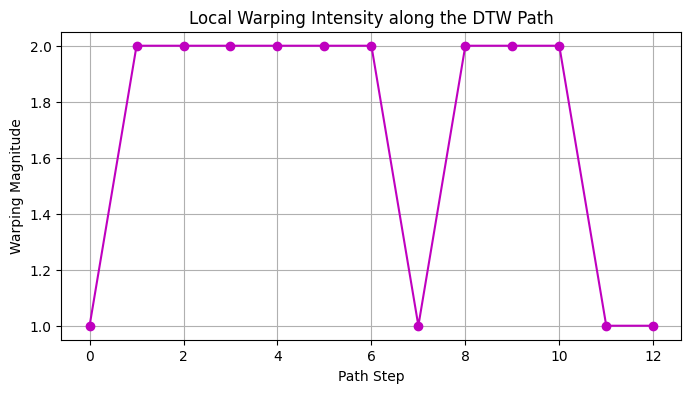

In [11]:
# Analyze local stretching or compression
stretch_zones = [abs(px[i+1]-px[i]) + abs(py[i+1]-py[i]) for i in range(len(px)-1)]
plt.figure(figsize=(8,4))
plt.plot(stretch_zones, 'm-o')
plt.title("Local Warping Intensity along the DTW Path")
plt.xlabel("Path Step")
plt.ylabel("Warping Magnitude")
plt.grid(True)
plt.show()


# Technical Interpretation of the Local Warping Intensity Plot

This plot shows the local warping magnitude (y-axis) at each step along the DTW path (x-axis). It measures how much one sequence (Vector 2) had to be stretched or compressed locally to align with the other (Vector 1).

Points with warping magnitude = 1 indicate one-to-one alignment, where both vectors move together smoothly in time.

Points where the value rises to 2 show time stretching or compression, meaning DTW had to match one point in one vector with two points in the other — a clear sign of local timing distortion.

The flat regions at magnitude 2 represent zones where one signal was temporarily slower or faster, while the dips back to 1 mark regions of perfect synchronization.

In simple terms:

This plot shows where and how much DTW had to “bend time” to make both sequences align.

When the line stays at 1, both vectors naturally align; when it jumps to 2, DTW is actively stretching or compressing time to correct small timing differences.